In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes plots show properly in Colab
%matplotlib inline


In [3]:
data = {
    "Study_Hours": [2,3,4,5,6,1,7,8,2.5,3.5,6.5,4.5,5.5,7.5,8.5],
    "Attendance": [60,65,70,75,80,55,85,90,68,72,78,74,82,88,92],
    "Previous_Score": [50,55,60,65,70,45,75,85,58,62,72,66,74,80,88],
    "Final_Score": [52,58,63,68,75,48,78,90,60,65,76,69,79,85,92]
}

df = pd.DataFrame(data)
df

,Study_Hours,Attendance,Previous_Score,Final_Score
0,2.0,60,50,52
1,3.0,65,55,58
2,4.0,70,60,63
3,5.0,75,65,68
4,6.0,80,70,75
5,1.0,55,45,48
6,7.0,85,75,78
7,8.0,90,85,90
8,2.5,68,58,60
9,3.5,72,62,65


In [4]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   Study_Hours  Attendance  Previous_Score  Final_Score
0          2.0          60              50           52
1          3.0          65              55           58
2          4.0          70              60           63
3          5.0          75              65           68
4          6.0          80              70           75

Last 5 rows:
    Study_Hours  Attendance  Previous_Score  Final_Score
10          6.5          78              72           76
11          4.5          74              66           69
12          5.5          82              74           79
13          7.5          88              80           85
14          8.5          92              88           92

Dataset Shape:
(15, 4)

Data Types:
Study_Hours       float64
Attendance          int64
Previous_Score      int64
Final_Score         int64
dtype: object

Missing Values:
Study_Hours       0
Attendance        0
Previous_Score    0
Final_Score       0
dtype: int64


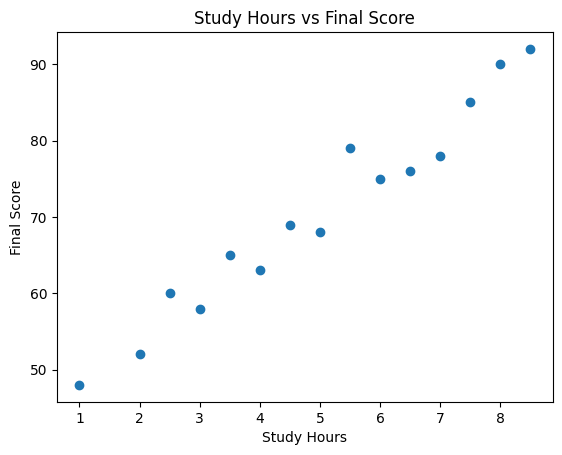

In [5]:
plt.figure()
plt.scatter(df["Study_Hours"], df["Final_Score"])
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

The scatter plot shows a positive linear relationship between Study Hours and Final Score. As study hours increase, the final score also increases. This indicates that study hours is a strong predictor of student performance.

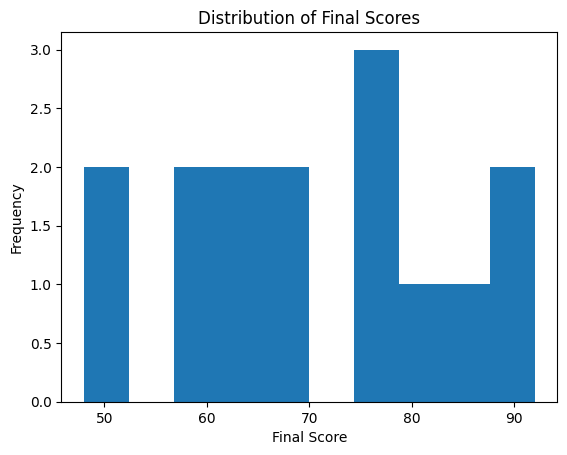

In [6]:
plt.figure()
plt.hist(df["Final_Score"])
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of final scores. Most students scored between 60 and 85 marks. The distribution appears slightly skewed toward higher scores, indicating generally good performance. There are no extreme outliers in the dataset.

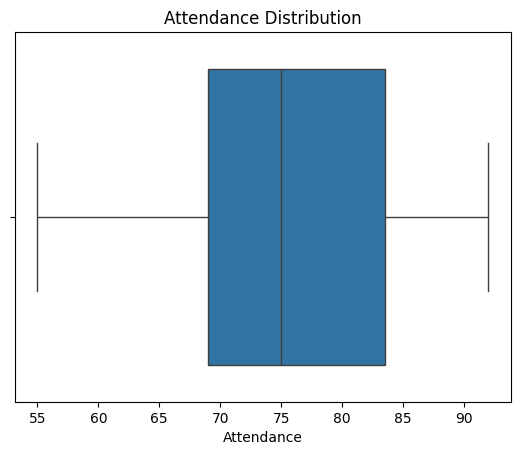

In [7]:
plt.figure()
sns.boxplot(x=df["Attendance"])
plt.title("Attendance Distribution")
plt.show()

The boxplot shows the distribution of attendance. The median attendance is around 75%, with values ranging from approximately 55% to 92%. There are no significant outliers, indicating consistent attendance levels across students.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [11]:
X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.5276225325737111
R2 Score: 0.9940393694663634


The Mean Absolute Error (MAE) is approximately 0.53, indicating that the model’s predictions differ from the actual values by less than 1 mark on average.
The R² score is 0.994, which means the model explains 99.4% of the variance in the final score.
This indicates an excellent linear relationship between the input features and the target variable.
The model performs very well on unseen test data.

In [15]:
X_reduced = df[["Study_Hours", "Attendance"]]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_r = LinearRegression()
model_r.fit(X_train_r, y_train_r)

y_pred_r = model_r.predict(X_test_r)

print("Reduced MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("Reduced R2:", r2_score(y_test_r, y_pred_r))

Reduced MAE: 0.3342644112235907
Reduced R2: 0.9973060522709724


After removing the "Previous_Score" feature, the model performance slightly improved. The R² score increased from 0.994 to 0.997 and MAE decreased. This suggests that Study Hours and Attendance are sufficient to predict Final Score in this dataset. Therefore, Previous_Score does not significantly improve prediction performance in this case.

In [19]:
df["Study_Attendance_Interaction"] = df["Study_Hours"] * df["Attendance"]

In [18]:
X_new = df[["Study_Hours", "Attendance", "Previous_Score", "Study_Attendance_Interaction"]]

In [20]:
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model_n = LinearRegression()
model_n.fit(X_train_n, y_train_n)

y_pred_n = model_n.predict(X_test_n)

print("New MAE:", mean_absolute_error(y_test_n, y_pred_n))
print("New R2:", r2_score(y_test_n, y_pred_n))

New MAE: 0.5307330078422675
New R2: 0.9939925832895047


Three models were compared: original, reduced, and feature-engineered.
The reduced model (Study Hours + Attendance) performed best with the highest R² score (0.997) and lowest MAE.
Adding the interaction feature did not improve performance.
This indicates that Study Hours and Attendance are the most important features for predicting Final Score in this dataset.
Simpler models can sometimes perform better on small datasets.

In [21]:
model_full = LinearRegression()
model_full.fit(X, y)

y_full_pred = model_full.predict(X)

print("Full Data R2:", r2_score(y, y_full_pred))
print("Full Data MAE:", mean_absolute_error(y, y_full_pred))

Full Data R2: 0.9970002582691616
Full Data MAE: 0.5890301043359353


When the model was trained and tested on the full dataset, the R² score slightly increased. However, this evaluation is not reliable because the model is being tested on the same data it was trained on.
This can lead to overfitting, where the model memorizes the training data instead of generalizing to new data.
Therefore, using a train-test split provides a more realistic estimate of model performance.